In [17]:
# ============================================================
# 1. Imports and paths
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Current notebook location: Milestone 2/backtest.ipynb
BACKTEST_DIR = Path("../backtest")
MILESTONE2_DIR = Path(".")

paths = {
    # Strategy 4
    "strategy4_buy": BACKTEST_DIR / "strategy4_buy_execution.csv",
    "strategy4_sell": BACKTEST_DIR / "strategy4_sell_execution.csv",

    # Strategy 5
    "strategy5_buy": BACKTEST_DIR / "strategy5_buy_improvement.xlsx",
    "strategy5_sell": BACKTEST_DIR / "strategy5_sell_improvement.xlsx",

    # Regime Ridge
    "regime_buy": MILESTONE2_DIR / "regime_ridge_buy_execution.csv",
    "regime_sell": MILESTONE2_DIR / "regime_ridge_sell_execution.csv",

    # Global Ridge
    "global_buy": MILESTONE2_DIR / "global_ridge_buy_execution.csv",
    "global_sell": MILESTONE2_DIR / "global_ridge_sell_execution.csv",

    # Regime Ridge + Strategy 5 fallback
    "regime_s5fb_buy": MILESTONE2_DIR / "regime_ridge_s5fallback_buy_execution.csv",
    "regime_s5fb_sell": MILESTONE2_DIR / "regime_ridge_s5fallback_sell_execution.csv",
}

for name, path in paths.items():
    print(name, "->", path, "| exists:", path.exists())

strategy4_buy -> ../backtest/strategy4_buy_execution.csv | exists: True
strategy4_sell -> ../backtest/strategy4_sell_execution.csv | exists: True
strategy5_buy -> ../backtest/strategy5_buy_improvement.xlsx | exists: True
strategy5_sell -> ../backtest/strategy5_sell_improvement.xlsx | exists: True
regime_buy -> regime_ridge_buy_execution.csv | exists: True
regime_sell -> regime_ridge_sell_execution.csv | exists: True
global_buy -> global_ridge_buy_execution.csv | exists: True
global_sell -> global_ridge_sell_execution.csv | exists: True
regime_s5fb_buy -> regime_ridge_s5fallback_buy_execution.csv | exists: True
regime_s5fb_sell -> regime_ridge_s5fallback_sell_execution.csv | exists: True


In [18]:
# ============================================================
# 2. Helper: load result file into standard format
# ============================================================

def load_strategy_result(path, strategy_name):
    """
    Standard output format:

        stock | average_improvement | strategy

    Supports CSV and Excel.
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    elif path.suffix.lower() in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")

    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    stock_candidates = [
        "stock", "Stock", "ticker", "Ticker", "stock_name", "stockName"
    ]

    improvement_candidates = [
        "average_improvement",
        "avg_improvement",
        "Average Improvement",
        "improvement",
        "Improvement",
        "BUY_Improvement",
        "SELL_Improvement",
    ]

    stock_col = next((c for c in stock_candidates if c in df.columns), None)
    improvement_col = next((c for c in improvement_candidates if c in df.columns), None)

    if stock_col is None:
        raise ValueError(
            f"Cannot find stock column in {path}. "
            f"Columns: {df.columns.tolist()}"
        )

    if improvement_col is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c != stock_col]

        if len(numeric_cols) == 0:
            raise ValueError(
                f"Cannot find improvement column in {path}. "
                f"Columns: {df.columns.tolist()}"
            )

        improvement_col = numeric_cols[0]

    out = df[[stock_col, improvement_col]].copy()
    out.columns = ["stock", "average_improvement"]
    out["strategy"] = strategy_name

    out["stock"] = out["stock"].astype(str)
    out["average_improvement"] = pd.to_numeric(
        out["average_improvement"],
        errors="coerce"
    )

    out = out.dropna(subset=["stock", "average_improvement"])

    return out

In [19]:
# ============================================================
# 3. Load Buy and Sell results
# ============================================================

buy_results = pd.concat(
    [
        load_strategy_result(paths["strategy4_buy"], "Strategy 4"),
        load_strategy_result(paths["strategy5_buy"], "Strategy 5"),
        load_strategy_result(paths["regime_buy"], "Regime Ridge"),
        load_strategy_result(paths["global_buy"], "Global Ridge"),
        load_strategy_result(paths["regime_s5fb_buy"], "Regime Ridge + S5 Fallback"),
    ],
    ignore_index=True
)

sell_results = pd.concat(
    [
        load_strategy_result(paths["strategy4_sell"], "Strategy 4"),
        load_strategy_result(paths["strategy5_sell"], "Strategy 5"),
        load_strategy_result(paths["regime_sell"], "Regime Ridge"),
        load_strategy_result(paths["global_sell"], "Global Ridge"),
        load_strategy_result(paths["regime_s5fb_sell"], "Regime Ridge + S5 Fallback"),
    ],
    ignore_index=True
)

print("Buy results:")
display(buy_results)

print("Sell results:")
display(sell_results)

Buy results:


,stock,average_improvement,strategy
0,AMZN,0.034198,Strategy 4
1,GOOG,0.050494,Strategy 4
2,INTC,0.001605,Strategy 4
3,MSFT,0.001728,Strategy 4
4,AMZN,0.031260,Strategy 5
5,GOOG,0.061740,Strategy 5
6,INTC,0.003560,Strategy 5
7,MSFT,0.004300,Strategy 5
8,AMZN,0.000123,Regime Ridge
9,GOOG,0.005556,Regime Ridge


Sell results:


,stock,average_improvement,strategy
0,AMZN,0.002716,Strategy 4
1,GOOG,0.028642,Strategy 4
2,INTC,0.000494,Strategy 4
3,MSFT,0.001481,Strategy 4
4,AMZN,0.013590,Strategy 5
5,GOOG,0.026810,Strategy 5
6,INTC,0.002220,Strategy 5
7,MSFT,0.002070,Strategy 5
8,AMZN,0.000988,Regime Ridge
9,GOOG,0.008025,Regime Ridge


In [20]:
# ============================================================
# 4. Plot grouped bar chart
# ============================================================

def plot_strategy_comparison(result_df, title, ylabel, save_path=None):
    """
    Plot average improvement per stock per strategy.
    """

    pivot = result_df.pivot_table(
        index="stock",
        columns="strategy",
        values="average_improvement",
        aggfunc="mean"
    )

    stock_order = ["AMZN", "GOOG", "INTC", "MSFT"]
    strategy_order = [
        "Strategy 4",
        "Strategy 5",
        "Regime Ridge",
        "Global Ridge",
        "Regime Ridge + S5 Fallback",
    ]

    pivot = pivot.reindex([s for s in stock_order if s in pivot.index])
    pivot = pivot[[s for s in strategy_order if s in pivot.columns]]

    ax = pivot.plot(
        kind="bar",
        figsize=(14, 6),
        width=0.78
    )

    ax.axhline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Stock")
    ax.set_ylabel(ylabel)
    ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=0)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return pivot

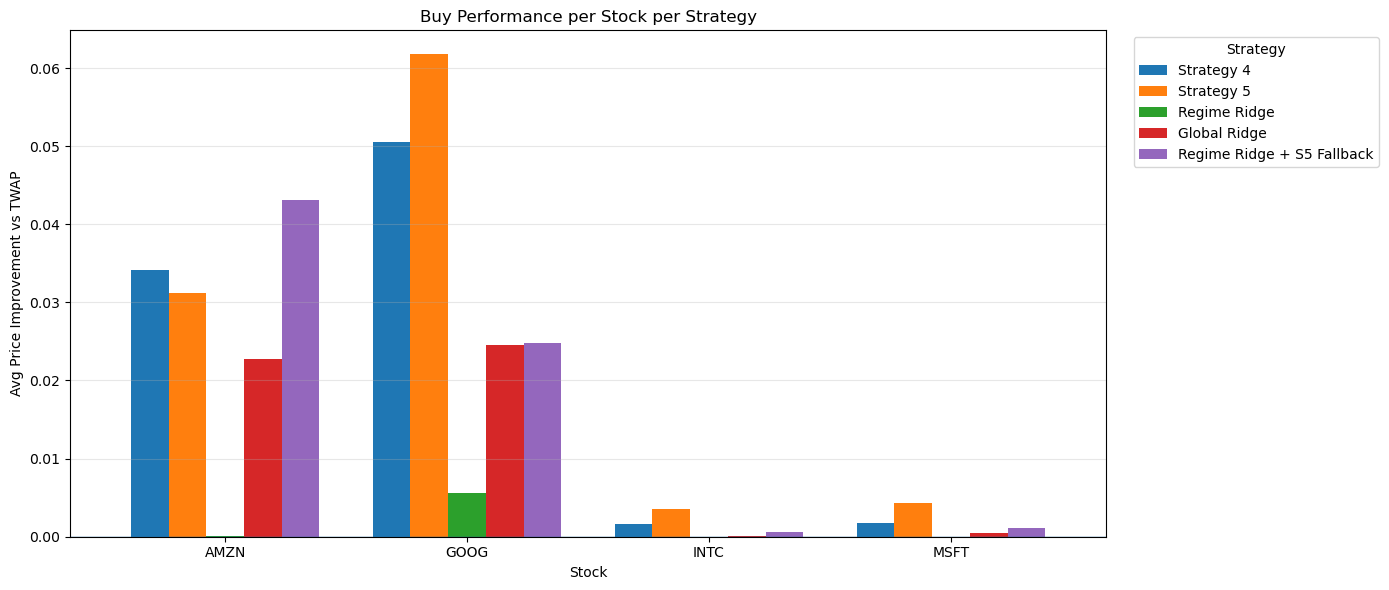

strategy,Strategy 4,Strategy 5,Regime Ridge,Global Ridge,Regime Ridge + S5 Fallback
stock,,,,,
AMZN,0.034198,0.03126,0.000123,0.022716,0.043086
GOOG,0.050494,0.06174,0.005556,0.024568,0.024815
INTC,0.001605,0.00356,0.000000,0.000123,0.000617
MSFT,0.001728,0.00430,0.000000,0.000494,0.001111


In [21]:
# ============================================================
# 5. Buy comparison chart
# ============================================================

buy_pivot = plot_strategy_comparison(
    buy_results,
    title="Buy Performance per Stock per Strategy",
    ylabel="Avg Price Improvement vs TWAP",
    save_path="buy_strategy_comparison_with_regime_s5fallback.png"
)

display(buy_pivot)

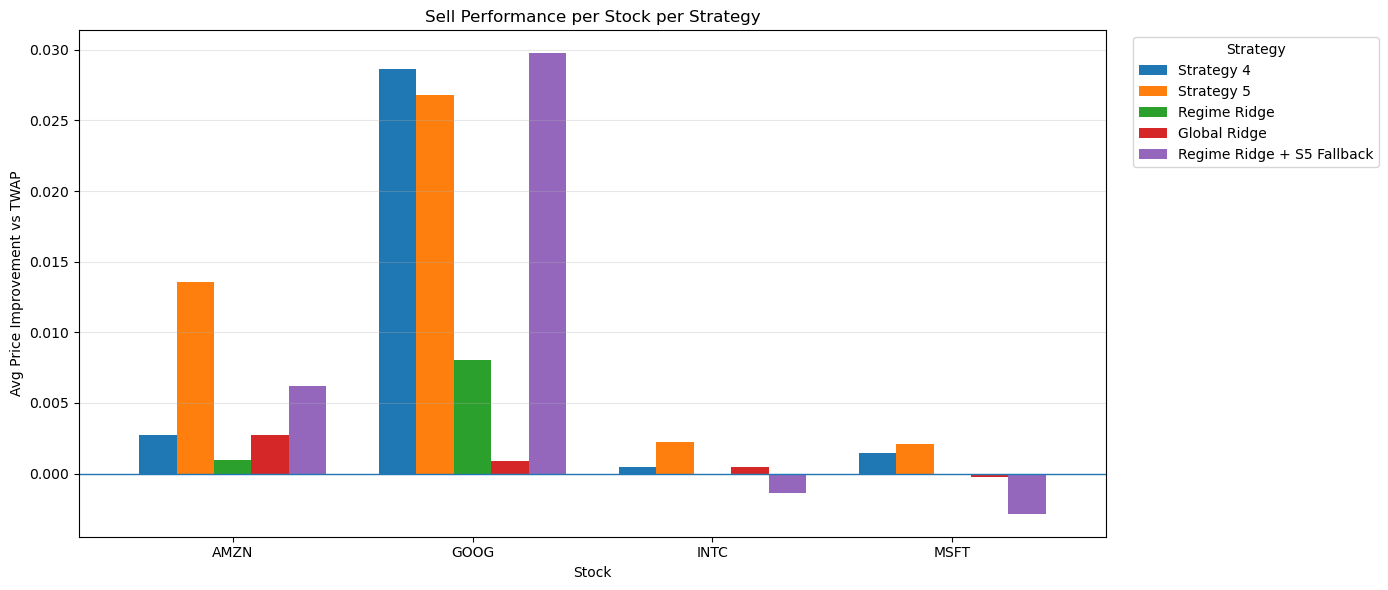

strategy,Strategy 4,Strategy 5,Regime Ridge,Global Ridge,Regime Ridge + S5 Fallback
stock,,,,,
AMZN,0.002716,0.01359,0.000988,0.002716,0.006173
GOOG,0.028642,0.02681,0.008025,0.000864,0.029753
INTC,0.000494,0.00222,0.000000,0.000494,-0.001358
MSFT,0.001481,0.00207,0.000000,-0.000247,-0.002840


In [22]:
# ============================================================
# 6. Sell comparison chart
# ============================================================

sell_pivot = plot_strategy_comparison(
    sell_results,
    title="Sell Performance per Stock per Strategy",
    ylabel="Avg Price Improvement vs TWAP",
    save_path="sell_strategy_comparison_with_regime_s5fallback.png"
)

display(sell_pivot)

In [23]:
# ============================================================
# 7. Overall average comparison
# ============================================================

buy_overall = (
    buy_results
    .groupby("strategy", as_index=False)["average_improvement"]
    .mean()
    .rename(columns={"average_improvement": "buy_avg_improvement"})
)

sell_overall = (
    sell_results
    .groupby("strategy", as_index=False)["average_improvement"]
    .mean()
    .rename(columns={"average_improvement": "sell_avg_improvement"})
)

overall_comparison = buy_overall.merge(
    sell_overall,
    on="strategy",
    how="outer"
)

overall_comparison["combined_avg_improvement"] = (
    overall_comparison["buy_avg_improvement"]
    + overall_comparison["sell_avg_improvement"]
) / 2

strategy_order = [
    "Strategy 4",
    "Strategy 5",
    "Regime Ridge",
    "Global Ridge",
    "Regime Ridge + S5 Fallback",
]

overall_comparison["strategy"] = pd.Categorical(
    overall_comparison["strategy"],
    categories=strategy_order,
    ordered=True
)

overall_comparison = overall_comparison.sort_values("strategy")

display(overall_comparison)

,strategy,buy_avg_improvement,sell_avg_improvement,combined_avg_improvement
3,Strategy 4,0.022006,0.008333,0.015170
4,Strategy 5,0.025215,0.011173,0.018194
1,Regime Ridge,0.001420,0.002253,0.001836
0,Global Ridge,0.011975,0.000957,0.006466
2,Regime Ridge + S5 Fallback,0.017407,0.007932,0.012670


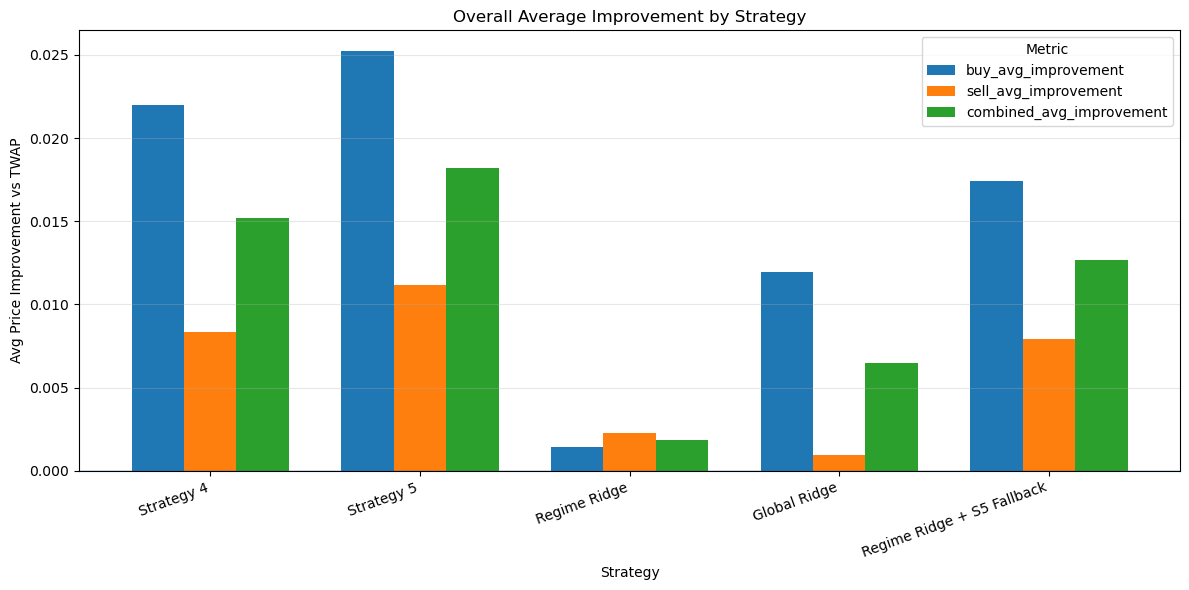

,buy_avg_improvement,sell_avg_improvement,combined_avg_improvement
strategy,,,
Strategy 4,0.022006,0.008333,0.015170
Strategy 5,0.025215,0.011173,0.018194
Regime Ridge,0.001420,0.002253,0.001836
Global Ridge,0.011975,0.000957,0.006466
Regime Ridge + S5 Fallback,0.017407,0.007932,0.012670


In [24]:
# ============================================================
# 8. Overall bar chart
# ============================================================

overall_plot = overall_comparison.set_index("strategy")[
    ["buy_avg_improvement", "sell_avg_improvement", "combined_avg_improvement"]
]

ax = overall_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

ax.axhline(0, linewidth=1)
ax.set_title("Overall Average Improvement by Strategy")
ax.set_xlabel("Strategy")
ax.set_ylabel("Avg Price Improvement vs TWAP")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("overall_strategy_comparison_with_regime_s5fallback.png", dpi=300, bbox_inches="tight")
plt.show()

display(overall_plot)

In [25]:
# ============================================================
# 9. Rank strategies by combined performance
# ============================================================

ranked_overall = overall_comparison.sort_values(
    "combined_avg_improvement",
    ascending=False
).reset_index(drop=True)

ranked_overall["rank"] = np.arange(1, len(ranked_overall) + 1)

display(
    ranked_overall[
        [
            "rank",
            "strategy",
            "buy_avg_improvement",
            "sell_avg_improvement",
            "combined_avg_improvement",
        ]
    ]
)

,rank,strategy,buy_avg_improvement,sell_avg_improvement,combined_avg_improvement
0,1,Strategy 5,0.025215,0.011173,0.018194
1,2,Strategy 4,0.022006,0.008333,0.015170
2,3,Regime Ridge + S5 Fallback,0.017407,0.007932,0.012670
3,4,Global Ridge,0.011975,0.000957,0.006466
4,5,Regime Ridge,0.001420,0.002253,0.001836
